In [1]:
import os

In [2]:
!pip install -qq fastai ddgs --use-deprecated=legacy-resolver

In [7]:
from ddgs import DDGS
from fastcore.all import *
import time,json

def search_images_ddg(keywords,max_images=200, retries=3):
    for i in range(retries):
        try:
            with DDGS() as ddgs:
                results=ddgs.images(keywords,max_results=max_images)
                if not results:
                    return L()
                return L(results).itemgot('image')
        except Exception as e:
            if i== retries - 1:
                print(f"Error searching for {keywords}:{e}")
                return L()
            time.sleep(2**i)
    return L()
    

In [8]:
search_images_ddg

<function __main__.search_images_ddg(keywords, max_images=200, retries=3)>

In [9]:
ims=search_images_ddg('grizzly bear')
len(ims)

42

Downloading image and viewing it

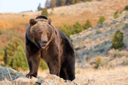

In [13]:
from fastdownload import download_url
from fastai.vision.all import *

dest = 'images/grizzly.jpg'
download_url(ims[0],dest,show_progress=False)
im=Image.open(dest)
im.to_thumb(128,128)

In [14]:
bear_types='grizzly','black','teddy'
path=Path('bears')


sort the types

In [16]:
if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest=(path/o)
        dest.mkdir(exist_ok=True)
        results=search_images_ddg(f'{o} bear')
        download_images(dest,urls=results)

In [17]:
fns=get_image_files(path)
fns

[Path('bears/grizzly/72382715-17e2-4f38-9475-37cd81c39bfb.jpg'), Path('bears/grizzly/2b0c0e4b-c18b-4ab9-a6f9-37f1abdd3be6.jpg'), Path('bears/grizzly/26969867-e089-4bc1-af33-d5ed9c4d7f71.jpg'), Path('bears/grizzly/4ca9d2e0-a718-4dfc-acdd-cbb736592e2a.jpg'), Path('bears/grizzly/89f35ca5-cc2f-4aa3-8b50-ac1f4b8db449.jpg'), Path('bears/grizzly/855ad912-114c-413c-8f97-308bf1d502f8.jpg'), Path('bears/grizzly/93f3ecb7-34d2-420a-b05a-b7a6de78bc0c.jpg'), Path('bears/grizzly/78e0223c-be5f-4255-b2f5-e526c19a96ff.jpg'), Path('bears/grizzly/1b26a5ac-c99e-4a95-998b-480df0f8b1aa.jpg'), Path('bears/grizzly/a5d1b400-cd7c-4b8b-9fbf-0ccd2da82ab8.jpg'), Path('bears/grizzly/40123b4d-4773-4ee2-ba47-f61c6c6be5f5.jpg'), Path('bears/grizzly/a54888e0-2076-4156-acb2-a9366f6ca45a.jpg'), Path('bears/grizzly/6e9d7020-8d77-4cb0-8018-f83424468ab2.jpg'), Path('bears/grizzly/8ff3ca29-363a-461a-aba3-ce9818fbe36f.jpg'), Path('bears/grizzly/fe1da487-b3d6-413a-8483-bb426345de93.webp'), Path('bears/grizzly/c27f73b4-9e8b-4f4a

In [18]:
failed=verify_images(fns)
failed

[]

In [19]:
failed.map(path.unlink);

train the model and then clean the data

In [22]:
bears=DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2,seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))

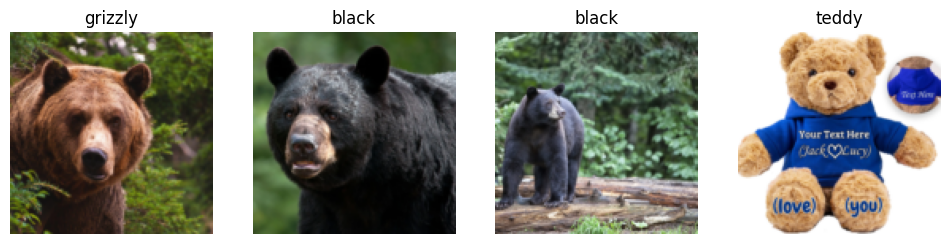

In [23]:
dls=bears.dataloaders(path)
dls.valid.show_batch(max_n=4,nrows=1)

New type of squish in resize images (to have whole image fitted)

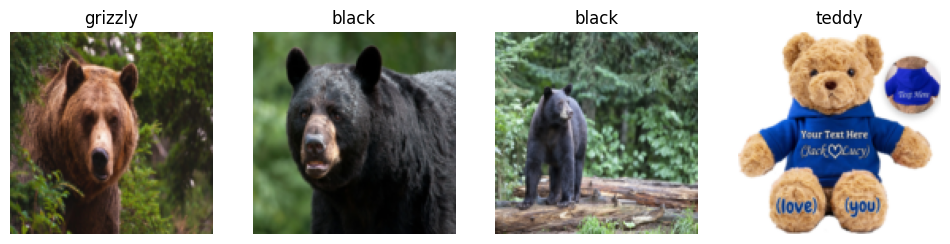

In [25]:
bears=bears.new(item_tfms=Resize(128,ResizeMethod.Squish))
dls=bears.dataloaders(path)

dls.valid.show_batch(max_n=4,nrows=1)

to get the whole image with the correct aspect ratio we use pad resize method

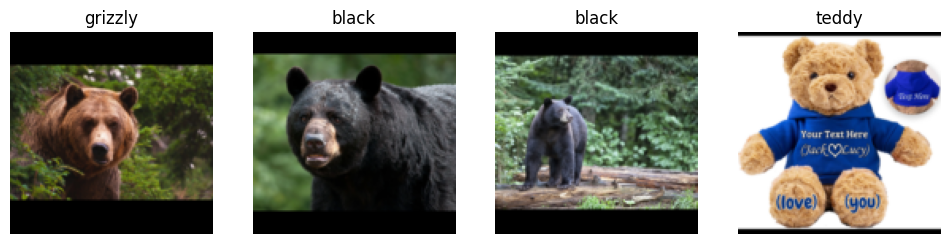

In [27]:
bears=bears.new(item_tfms=Resize(128,ResizeMethod.Pad,pad_mode='zeros'))
dls=bears.dataloaders(path)
dls.valid.show_batch(max_n=4,nrows=1)

random resized crops to get random sized pictures (data augmentation)

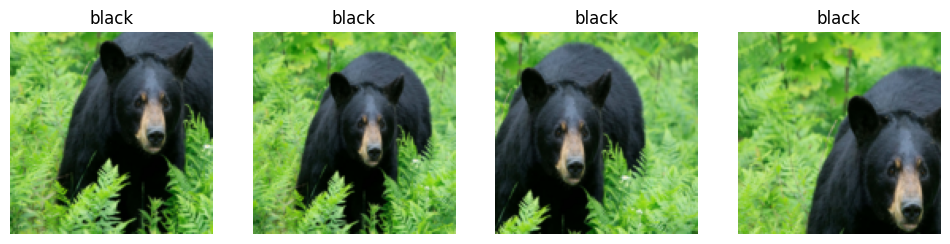

In [30]:
bears=bears.new(item_tfms=RandomResizedCrop(128,min_scale=0.3))
dls=bears.dataloaders(path)
dls.train.show_batch(max_n=4,nrows=1,unique=True) #unique true makes the same image appear

data augmentation

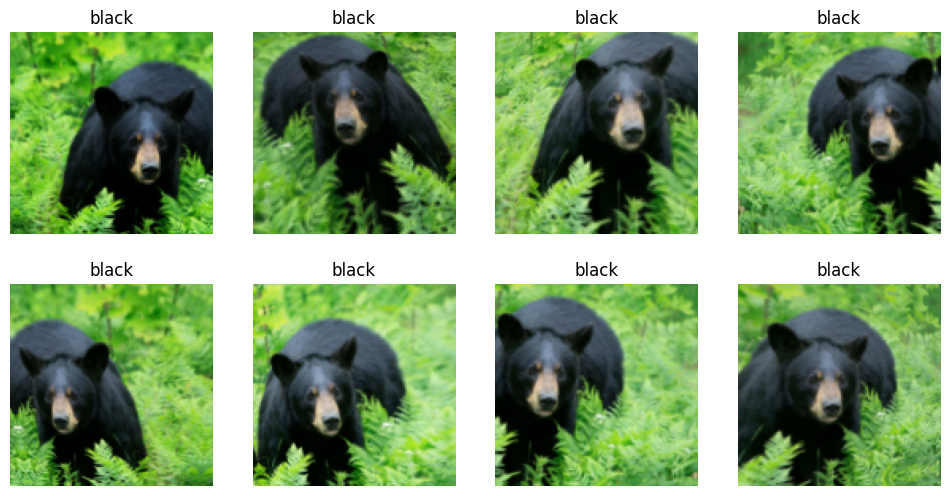

In [33]:
bears=bears.new(item_tfms=Resize(128),batch_tfms=aug_transforms())
dls=bears.dataloaders(path)
dls.train.show_batch(max_n=8,nrows=2,unique=True)

In [34]:
bears=bears.new(item_tfms=RandomResizedCrop(224,min_scale=0.5), batch_tfms=aug_transforms())
dls=bears.dataloaders(path)

In [35]:
learn=vision_learner(dls,resnet18,metrics=error_rate)

[W523 14:56:29.161134659 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.200448137 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.200839771 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.213700634 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.258496446 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.301749499 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.341462285 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.351142440 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.357069693 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:56:29.357779243 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W523 14:5

In [36]:
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.113835,2.816560,0.421053,00:23


epoch,train_loss,valid_loss,error_rate,time
0,2.008910,1.771357,0.421053,00:22
1,1.889668,0.600645,0.157895,00:22
2,1.390027,0.233918,0.105263,00:22
3,1.071667,0.142051,0.105263,00:23


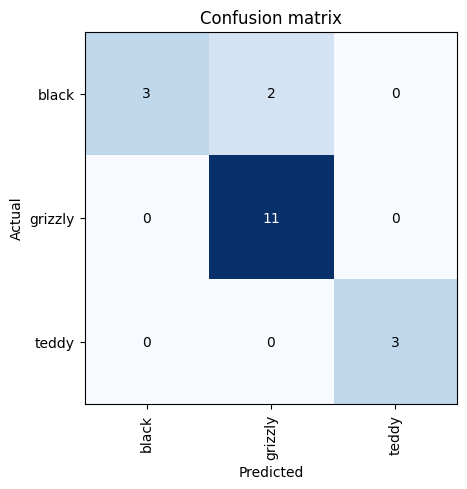

In [37]:
interp=ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Tell us where the loss is the highest

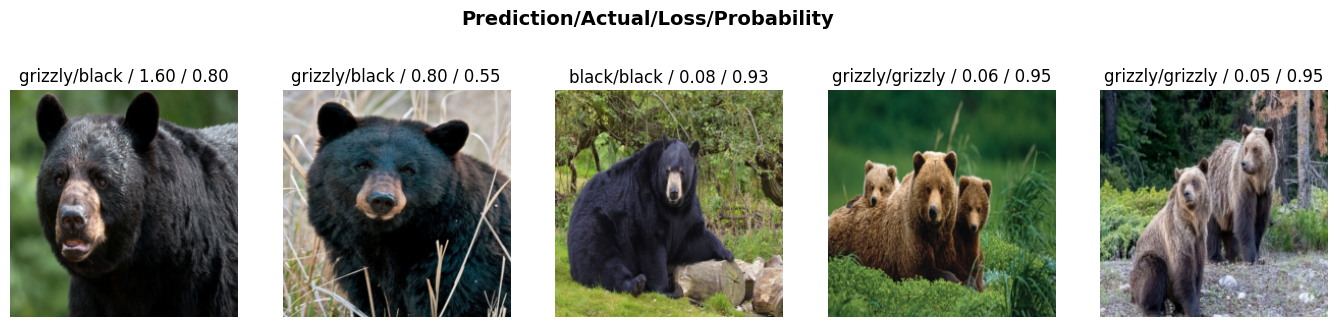

In [38]:
interp.plot_top_losses(5,nrows=1,figsize=(17,4))

Removing wrongly labeled images from dataset

In [43]:
from fastai.vision.widgets import *
cleaner=ImageClassifierCleaner(learn)
cleaner

making changes

In [46]:
for idx in cleaner.delete():cleaner.fns[idx].unlink()
for idx,cat in cleaner.change():shutil.move(str(cleaner.fns[idx]),path/cat)

--------------------------------------------------------------------------------------------